in this notebook, we will be working on a dataset of used cars. The dataset contains various features of the cars such as make, model, year, mileage, price, and more. Our goal is to analyze the data and build a predictive model to estimate the price of a used car based on its features.

In [73]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split, cross_val_score, KFold, cross_validate
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer, TargetEncoder
from sklearn.feature_extraction import FeatureHasher
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.model_selection import cross_val_score
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.svm import SVR
from xgboost import XGBRegressor
from columnTransform import AddDropFeatures, to_string_func
from datetime import date
import joblib
import json
import os

In [4]:
df = pd.read_csv("pre-owned cars.csv")
df.shape

(2806, 15)

In [5]:
df.head()

,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
0,Mahindra,Thar LX D 4WD MT CONVERTIBLE,Manual,2020.0,01-01-2021,Diesel,2184.0,11003.0,1st owner,1231000,23431.0,True,No,HR26,2020 Mahindra Thar LX D 4WD MT CONVERTIBLE
1,Hyundai,Verna 1.6 VTVT SX,Manual,2018.0,01-07-2018,Petrol,1591.0,66936.0,1st owner,786000,15359.0,True,No,DL7C,2018 Hyundai Verna 1.6 VTVT SX
2,Tata,Harrier XT PLUS 2.0L KRYOTEC DARK EDITON,Manual,2022.0,01-08-2022,Diesel,1956.0,27990.0,1st owner,1489000,28349.0,True,No,HR29,2022 Tata Harrier XT PLUS 2.0L KRYOTEC DARK ED...
3,Honda,City 1.5L I-VTE V CVT,Automatic,2023.0,01-04-2023,Petrol,1498.0,5061.0,1st owner,1227000,23355.0,True,Yes,DL4C,2023 Honda City 1.5L I-VTE V CVT
4,Ford,Ecosport TITANIUM 1.5L DIESEL,Manual,2021.0,01-07-2021,Diesel,1498.0,23480.0,1st owner,887000,16883.0,True,No,UP14,2021 Ford Ecosport TITANIUM 1.5L DIESEL


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2806 entries, 0 to 2805
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2805 non-null   object 
 1   model                2805 non-null   object 
 2   transmission         2805 non-null   object 
 3   make_year            2805 non-null   float64
 4   reg_year             720 non-null    object 
 5   fuel_type            2805 non-null   object 
 6   engine_capacity(CC)  2688 non-null   float64
 7   km_driven            2805 non-null   float64
 8   ownership            2805 non-null   object 
 9   price                2806 non-null   int64  
 10  overall_cost         2805 non-null   float64
 11  has_insurance        2805 non-null   object 
 12  spare_key            2805 non-null   object 
 13  reg_number           2805 non-null   object 
 14  title                2805 non-null   object 
dtypes: float64(4), int64(1), object(10)
me

In [7]:
df.describe()

,make_year,engine_capacity(CC),km_driven,price,overall_cost
count,2805.000000,2688.000000,2805.000000,2.806000e+03,2805.000000
mean,2018.181105,1259.027530,49215.477362,1.342522e+06,13495.022816
std,2.945293,254.504798,26626.932696,3.554669e+07,6040.809220
min,2010.000000,624.000000,450.000000,1.630000e+05,4039.000000
25%,2016.000000,1194.000000,28540.000000,4.350000e+05,9267.000000
50%,2018.000000,1197.000000,45695.000000,5.940000e+05,12145.000000
75%,2021.000000,1462.000000,68182.000000,8.140000e+05,15760.000000
max,2024.000000,2694.000000,143991.000000,1.883558e+09,47338.000000


# data preprocessing

In [8]:
# missing values checking
missing_percent = df.isna().sum() / len(df) * 100
missing_data = pd.DataFrame({"missing value count": df.isna().sum(), "missing percent": missing_percent})
missing_data.sort_values(by="missing percent", ascending=False)

,missing value count,missing percent
reg_year,2086,74.340699
engine_capacity(CC),118,4.205274
brand,1,0.035638
model,1,0.035638
transmission,1,0.035638
make_year,1,0.035638
fuel_type,1,0.035638
km_driven,1,0.035638
ownership,1,0.035638
overall_cost,1,0.035638


we note that 'reg_year' are mostly missing(~75%), making it more probably to be a non-informative feature and can be droped."engine_capacity" has near 5% missing values, it can be imputed by median, but better if this missing is at random we can use value of car with same model and brand to impute the missing values. all other features exczpt price has exactly 1 missing values

In [9]:
# check if that 1 missing values is one row or more than one row
print(df[df["title"].isna()])

     brand model transmission  make_year reg_year fuel_type  \
2805   NaN   NaN          NaN        NaN      NaN       NaN   

      engine_capacity(CC)  km_driven ownership       price  overall_cost  \
2805                  NaN        NaN       NaN  1883558000           NaN   

     has_insurance spare_key reg_number title  
2805           NaN       NaN        NaN   NaN  


In [10]:
print(df.iloc[2805])

brand                         NaN
model                         NaN
transmission                  NaN
make_year                     NaN
reg_year                      NaN
fuel_type                     NaN
engine_capacity(CC)           NaN
km_driven                     NaN
ownership                     NaN
price                  1883558000
overall_cost                  NaN
has_insurance                 NaN
spare_key                     NaN
reg_number                    NaN
title                         NaN
Name: 2805, dtype: object


we find that the 1 missing value in the 'title' column is only one row, so we can drop that row from the dataset.

In [11]:
sup_prices = df["price"].iloc[:2805].sum()

In [12]:
df_clean = df.drop(index=2805, axis=0)

In [13]:
df_clean.shape

(2805, 15)

next, we will check for any duplicate rows in the dataset and remove them if found. Duplicate rows can lead to biased results and affect the performance of our predictive model.

In [14]:
df_clean[df_clean.duplicated()]

,brand,model,transmission,make_year,reg_year,fuel_type,engine_capacity(CC),km_driven,ownership,price,overall_cost,has_insurance,spare_key,reg_number,title
1617,Hyundai,NEW SANTRO SPORTZ MT,Manual,2019.0,NaN,Petrol,1086.0,33811.0,1st owner,483000,9442.0,True,No,KA05,2019 Hyundai NEW SANTRO SPORTZ MT


In [15]:
# there is one duplicate row in the dataset, we will drop it to avoid bias in our model.
df_clean = df_clean.drop_duplicates()

return to "reg_year" and "engine_capacity" columns, we will handle the missing values in these columns. For "reg_year", we check if it is highly correlated to "make_year" since usually the registration year is the same as the make year, if it is highly correlated we can drop "reg_year" and keep "make_year".

In [16]:
df_year = pd.DataFrame({'make_year': df['make_year'], "reg_year": pd.to_numeric(df["reg_year"].str[-4:], errors='coerce')})

In [17]:
df_year.head()

,make_year,reg_year
0,2020.0,2021.0
1,2018.0,2018.0
2,2022.0,2022.0
3,2023.0,2023.0
4,2021.0,2021.0


In [18]:
df_year.shape

(2806, 2)

In [19]:
df_year["make_year"].corr(df_year["reg_year"])

np.float64(0.9946266707693698)

correlation between "reg_year" and "make_year" is 0.99, which is very high, so we will drop "reg_year" and keep "make_year".

In [20]:
df_year= df_year.dropna()

In [21]:
df_year.shape

(720, 2)

In [22]:
df_year["make_year"].corr(df_year["reg_year"])

np.float64(0.9946266707693698)

In [23]:
df_clean.drop(columns=["reg_year"], inplace=True)

In [24]:
df.groupby('brand')['reg_year'].apply(lambda x: x.isna().mean()).sort_values()

brand
Jeep          0.500000
Mahindra      0.657895
Nissan        0.657895
Ford          0.687500
MG            0.702703
Tata          0.716667
Honda         0.728261
KIA           0.732759
Maruti        0.732973
Datsun        0.735294
Toyota        0.750000
Renault       0.772455
Hyundai       0.780303
Volkswagen    0.849057
Skoda         0.969697
Name: reg_year, dtype: float64

In [25]:
df_clean.groupby('model')['engine_capacity(CC)'].mean().sort_values(ascending=False).head(10)

model
Innova Crysta 2.7 VX 7 STR           2694.0
Thar CRDE 4X4 AC                     2498.0
XUV700 AX 7 LUXURY D AT 7 STR        2184.0
XUV700 AX 7 LUXURY D AWD AT 7 STR    2184.0
XUV700 AX 3 D AT 5 STR               2184.0
Thar LX D 4*4 MT HT                  2184.0
Thar LX D 4WD AT CONVERTIBLE         2184.0
Thar LX D 4WD MT CONVERTIBLE         2184.0
XUV700 AX 5 D MT 5 STR               2184.0
XUV500 W6                            2179.0
Name: engine_capacity(CC), dtype: float64

In [26]:
df_clean.groupby('model')['engine_capacity(CC)'].std().sort_values(ascending=False).head(10)

model
Duster RXL PETROL                   57.735027
Ecosport TITANIUM 1.5L PETROL AT     1.264911
Ecosport TITANIUM 1.5L PETROL        1.029857
NEXON XZ PLUS PETROL DUAL TONE       0.577350
NEXON XM PETROL                      0.547723
NEXON XZ PLUS PETROL                 0.527046
NEXON XZA PLUS PETROL                0.516398
Amaze 1.2L I-VTEC S                  0.508548
City 1.5L I-VTEC ZX CVT              0.468807
City 1.5L I-VTEC ZX                  0.447214
Name: engine_capacity(CC), dtype: float64

In [27]:
# 'Duster RXL PETROL' has the heighest standard deviation in engine capacity, we will check the make_year and engine_capacity for this model to see if there are any outliers or anomalies.
df_clean[df_clean['model'].str.contains('Duster RXL PETROL', na=False)][['model', 'make_year', 'engine_capacity(CC)']].sort_values('make_year')

,model,make_year,engine_capacity(CC)
214,Duster RXL PETROL,2013.0,1598.0
1084,Duster RXL PETROL,2017.0,1498.0
1440,Duster RXL PETROL,2017.0,1498.0


for table above it looks like it is input mistake lead to the high standard deviation in engine capacity for the model 'Duster RXL PETROL', since two rows has value 1498 and one 1598.\
to check if model alone enough or we may include brande, we need to check if any of those has missing "engine_capacity" has unique model value on the dataset.

In [28]:
missing_engine_capacity = df_clean[df_clean['engine_capacity(CC)'].isna()]
missing_engine_capacity_models = missing_engine_capacity['model'].unique()
for model in missing_engine_capacity_models:
    print(f" {model} has {df_clean['model'].value_counts()[model]} occurence")

 NEXON XMA DIESEL has 1 occurence
 Creta E PLUS 1.6 PETROL has 21 occurence
 NEW I20 Sportz (O) 1.2 IVT has 1 occurence
 SELTOS HTK PLUS 1.5 has 4 occurence
 City 1.5L I-VTEC VX has 10 occurence
 XL6 ALPHA PLUS  AT DUAL TONE has 1 occurence
 Amaze 1.2L I-VTEC S has 30 occurence
 Wagon R 1.0 LXI CNG has 25 occurence
 Kwid RXL has 6 occurence
 TIGOR XZ PLUS PETROL has 6 occurence
 Kwid CLIMBER 1.0 (O) DUAL TONE has 1 occurence
 Kwid RXT 0.8 has 9 occurence
 Dzire VXI has 13 occurence
 Grand i10 SPORTZ 1.2 KAPPA VTVT has 45 occurence
 Baleno ALPHA PETROL 1.2 has 17 occurence
 NEXON EV XZ PLUS has 2 occurence
 i20 MAGNA (O) 1.2 has 4 occurence
 Celerio VXI AMT has 23 occurence
 Grand i10 MAGNA 1.2 KAPPA VTVT has 21 occurence
 TIAGO EV XT LONG RANGE has 1 occurence
 i10 ERA 1.1 has 3 occurence
 XUV300 W6 1.5 DIESEL has 3 occurence
 SELTOS GTX PLUS AT 1.5 DIESEL has 4 occurence
 Amaze 1.2L I-VTEC E has 2 occurence
 Jazz 1.2L I-VTEC V CVT has 3 occurence
 TIGOR XZ PLUS CNG LEATHERETTE PACK ha

many of those missing "engine_capacity" has unique model value on the dataset, so wr can't use model alone to impute the missing values in "engine_capacity" column. we wiill use hirarchical checking: model then brand+fueltype then brand, and if still missing we will use median of the whole dataset to impute the missing values in "engine_capacity" column.

In [ ]:
def impute_missing_engine_capacity(df):
    # Create a copy of the DataFrame to avoid modifying the original
    df_copy = df.copy()

    # Step 1: Impute based on model
    model_medians = df_copy.groupby('model')['engine_capacity(CC)'].median()
    df_copy['engine_capacity(CC)'] = df_copy.apply(
        lambda row: model_medians[row['model']] if pd.isna(row['engine_capacity(CC)']) else row['engine_capacity(CC)'],
        axis=1
    )

    # Step 2: Impute based on brand and fuel type
    brand_fuel_medians = df_copy.groupby(['brand', 'fuel_type'])['engine_capacity(CC)'].median()
    df_copy['engine_capacity(CC)'] = df_copy.apply(
        lambda row: brand_fuel_medians[row['brand'], row['fuel_type']] if pd.isna(row['engine_capacity(CC)']) else row['engine_capacity(CC)'],
        axis=1
    )

    # Step 3: Impute based on brand only
    brand_medians = df_copy.groupby('brand')['engine_capacity(CC)'].median()
    df_copy['engine_capacity(CC)'] = df_copy.apply(
        lambda row: brand_medians[row['brand']] if pd.isna(row['engine_capacity(CC)']) else row['engine_capacity(CC)'],
        axis=1
    )

    # Step 4: Impute remaining missing values with the overall median
    overall_median = df_copy['engine_capacity(CC)'].median()
    df_copy['engine_capacity(CC)'].fillna(overall_median, inplace=True)

    return df_copy

In [89]:
# Create a temporary flag for missingness
missing_mask = df_clean['engine_capacity(CC)'].isna()
df_clean = impute_missing_engine_capacity(df_clean)

C:\Users\Dell\AppData\Local\Temp\ipykernel_18228\2286318837.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_copy['engine_capacity(CC)'].fillna(overall_median, inplace=True)


In [31]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2804 entries, 0 to 2804
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2804 non-null   object 
 1   model                2804 non-null   object 
 2   transmission         2804 non-null   object 
 3   make_year            2804 non-null   float64
 4   fuel_type            2804 non-null   object 
 5   engine_capacity(CC)  2804 non-null   float64
 6   km_driven            2804 non-null   float64
 7   ownership            2804 non-null   object 
 8   price                2804 non-null   int64  
 9   overall_cost         2804 non-null   float64
 10  has_insurance        2804 non-null   object 
 11  spare_key            2804 non-null   object 
 12  reg_number           2804 non-null   object 
 13  title                2804 non-null   object 
dtypes: float64(4), int64(1), object(9)
memory usage: 328.6+ KB


# analysing numerical features

In [32]:
df_numeric = df_clean.select_dtypes(include=["number"]).columns.tolist()
df_numeric

['make_year', 'engine_capacity(CC)', 'km_driven', 'price', 'overall_cost']

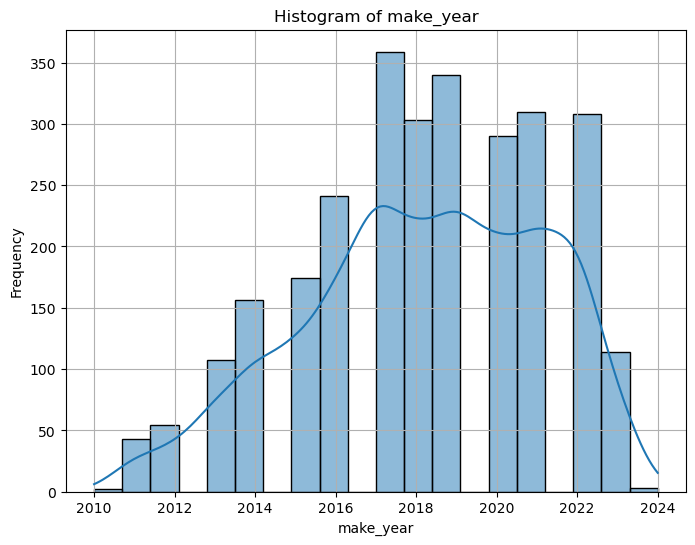

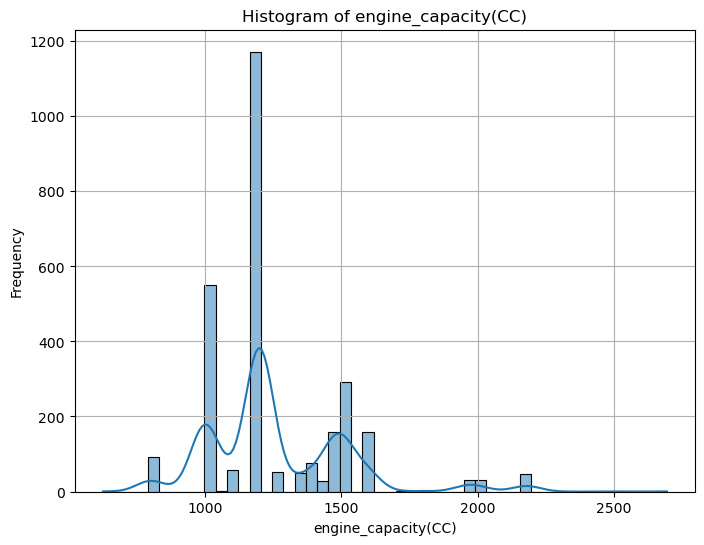

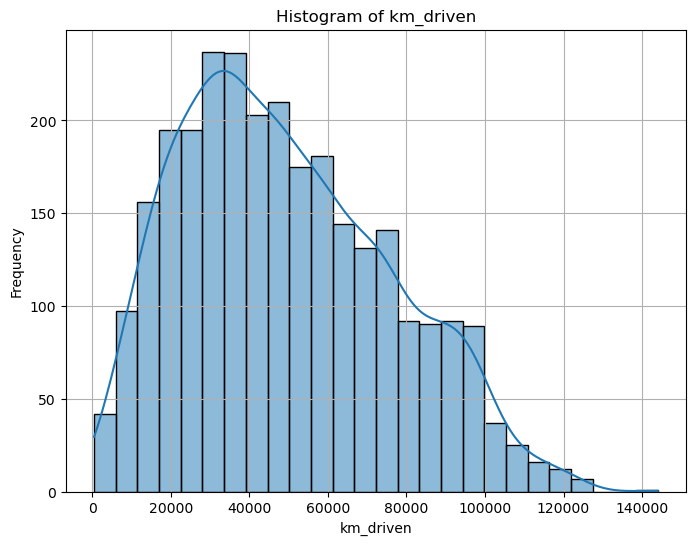

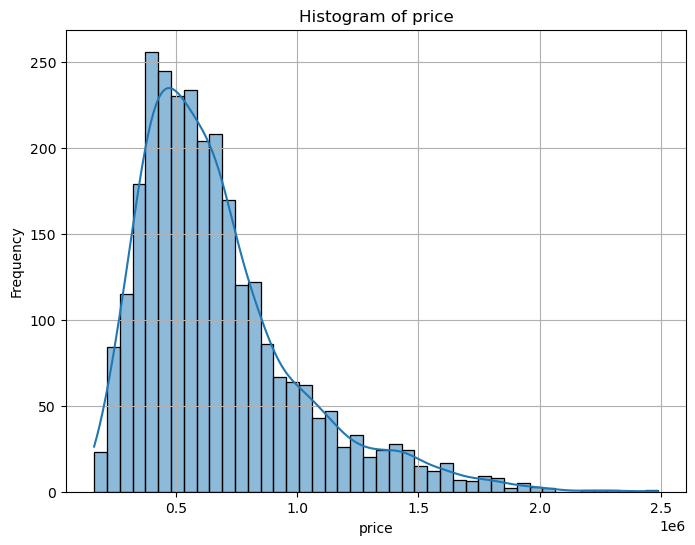

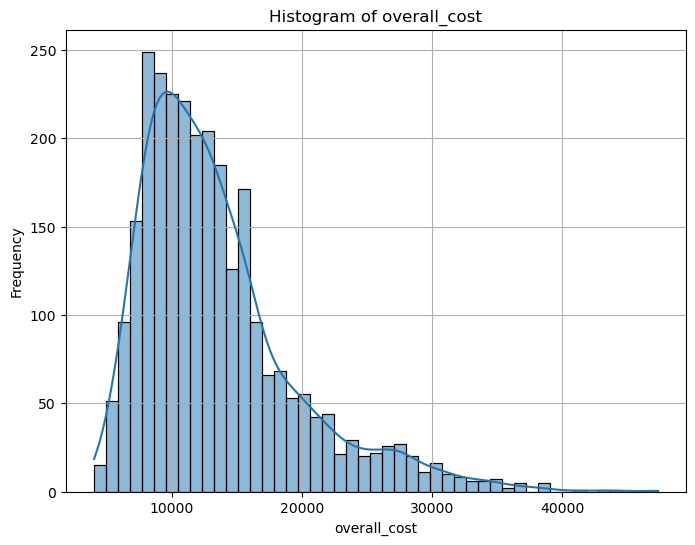

In [33]:
# histogram of numerical features
for column in df_numeric:
    plt.figure(figsize=(8, 6))
    sns.histplot(df_clean[column], kde=True)
    plt.title(f'Histogram of {column}')
    plt.xlabel(column)
    plt.ylabel('Frequency')
    plt.grid(True)
    plt.show()

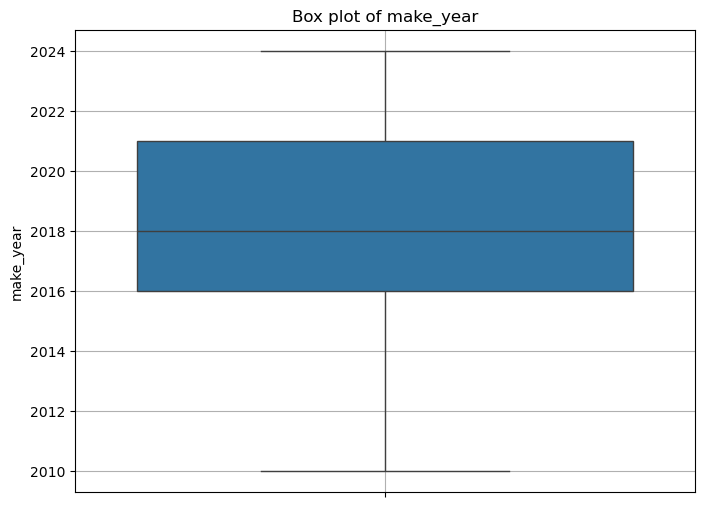

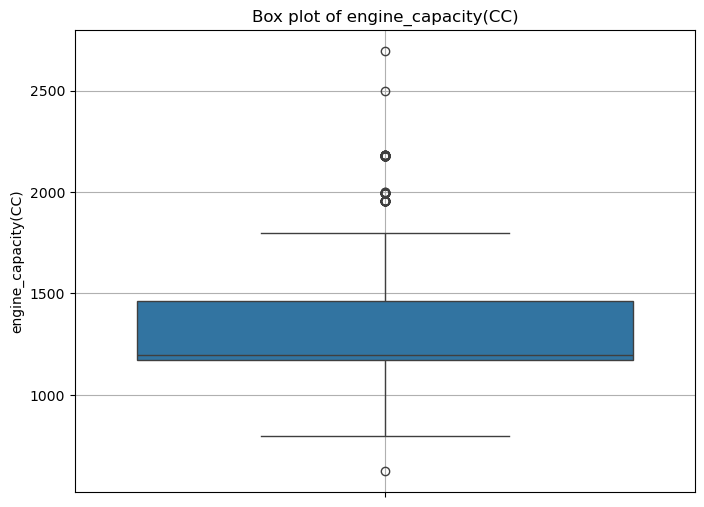

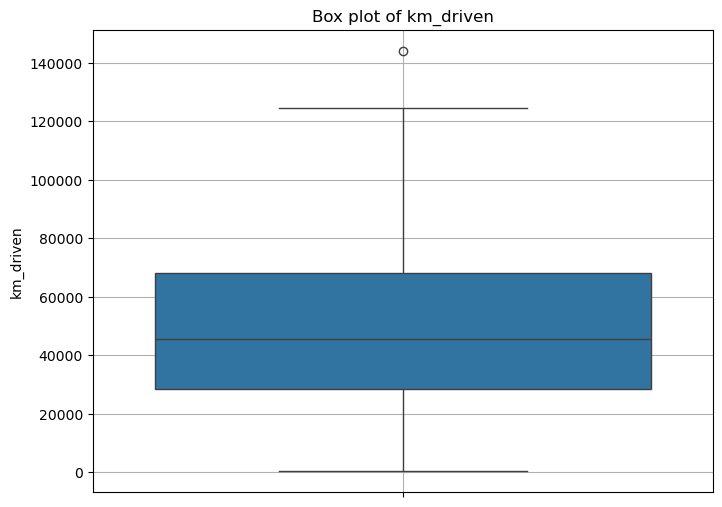

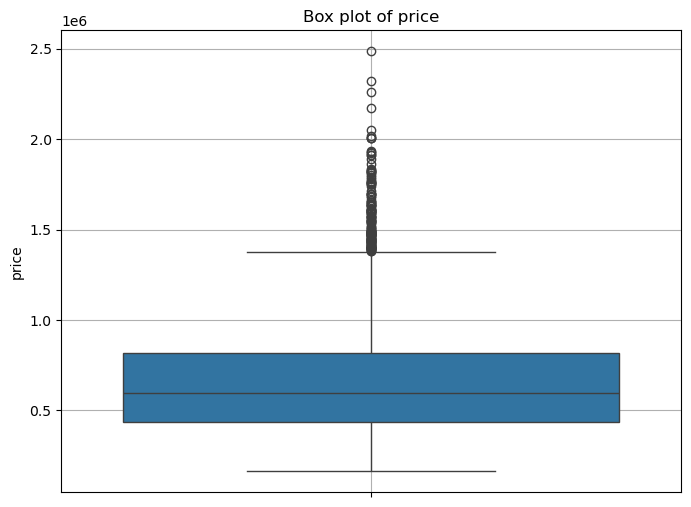

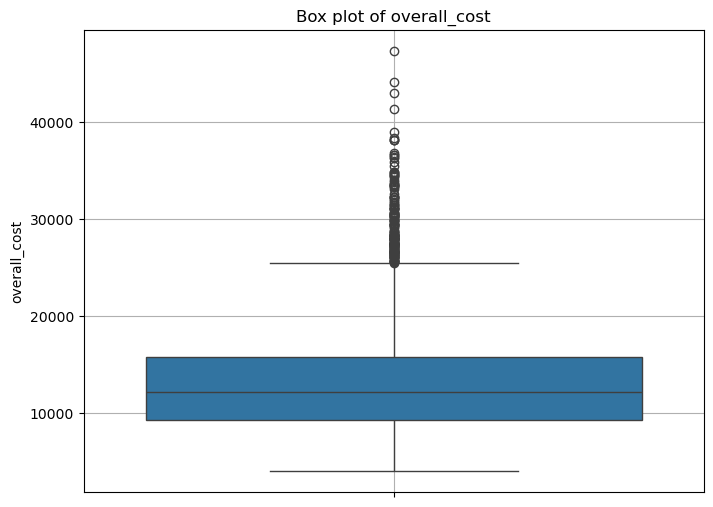

In [34]:
# boxplot of numerical features
for column in df_numeric:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df_clean[column])
    plt.title(f'Box plot of {column}')
    plt.ylabel(column)
    plt.grid(True)
    plt.show()

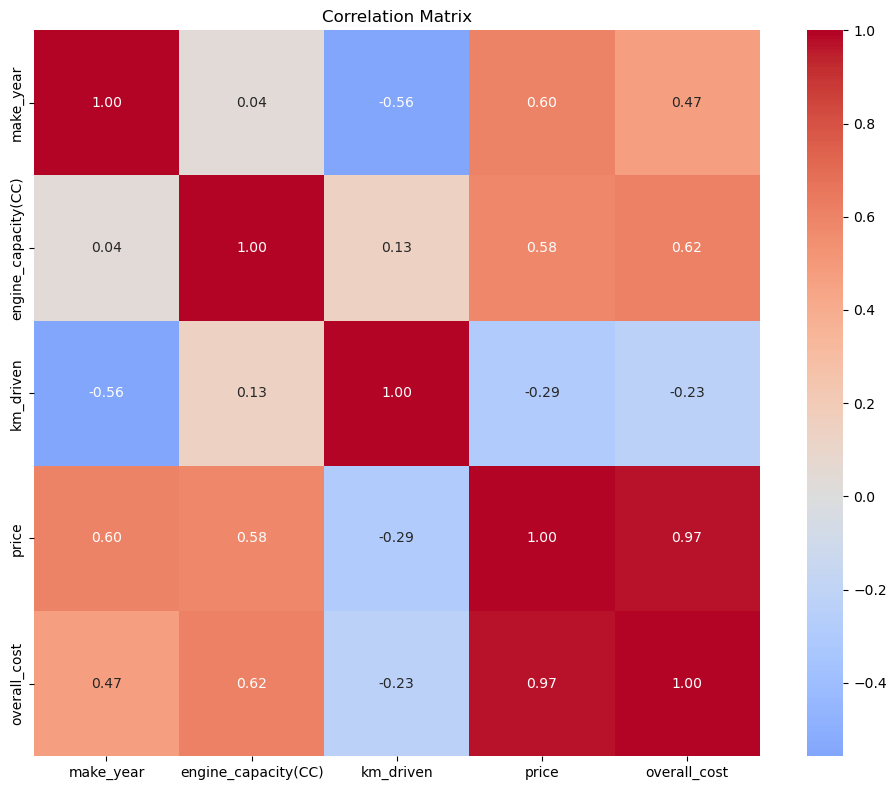

In [35]:
plt.figure(figsize=(10, 8))
corr_matrix = df_clean.select_dtypes(include=["number"]).corr()
sns.heatmap(corr_matrix, 
            annot=True,        
            cmap='coolwarm',   
            center=0,          
            square=True,      
            fmt='.2f')         
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [36]:
df_skew = df_clean[df_numeric].skew().sort_values(ascending=False)
df_skew

overall_cost           1.443803
price                  1.395217
engine_capacity(CC)    1.223183
km_driven              0.456795
make_year             -0.354071
dtype: float64

overall_cost is strongly correlated to price(target), and has identical distribution, so we can drop overall_cost and keep price since it may lead to a leakage. there is no other strong correlation between numeirical features, but we can notice that km_drive and price has negative linear correlation, this expected because when a car is driven more it may affect it status and reduce price.\
target price is right skewed so we need to apply log transform on it

In [37]:
df_clean['price'] = np.log1p(df['price'])
df_skew = df_clean[df_numeric].skew().sort_values(ascending=False)
df_skew

overall_cost           1.443803
engine_capacity(CC)    1.223183
km_driven              0.456795
price                  0.144899
make_year             -0.354071
dtype: float64

In [87]:
df_clean['price'].describe()

count    2804.000000
mean       13.309528
std         0.460454
min        12.001512
25%        12.983104
50%        13.294636
75%        13.609717
max        14.726588
Name: price, dtype: float64

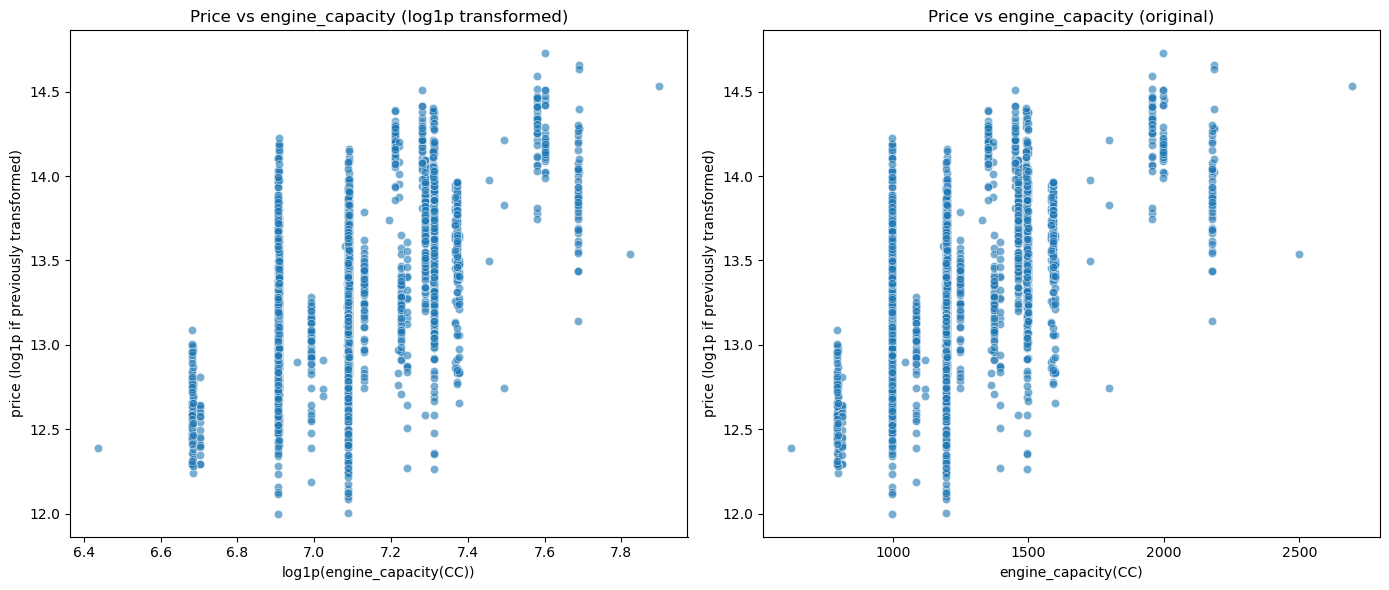

In [38]:
# create copy and transformed column
df_team = df_clean.copy()
df_team['engine_capacity_CC_transformed'] = np.log1p(df_team['engine_capacity(CC)'])

# two scatter plots side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(ax=axes[0],
                x='engine_capacity_CC_transformed',
                y='price',
                data=df_team,
                alpha=0.6)
axes[0].set_title('Price vs engine_capacity (log1p transformed)')
axes[0].set_xlabel('log1p(engine_capacity(CC))')
axes[0].set_ylabel('price (log1p if previously transformed)')

sns.scatterplot(ax=axes[1],
                x='engine_capacity(CC)',
                y='price',
                data=df_team,
                alpha=0.6)
axes[1].set_title('Price vs engine_capacity (original)')
axes[1].set_xlabel('engine_capacity(CC)')
axes[1].set_ylabel('price (log1p if previously transformed)')

plt.tight_layout()
plt.show()

In [39]:
df.drop(columns=['overall_cost'], inplace=True)

In [40]:
for col in df_clean.select_dtypes(include="object").columns:
    print(f"{col}: {df_clean[col].nunique()}")

brand: 15
model: 818
transmission: 2
fuel_type: 4
ownership: 3
has_insurance: 1
spare_key: 2
reg_number: 157
title: 1530


for categorical features, "transmission" and "spare_key" have two unique values, we can consider them a binary features and encode them 1 and 0."model" and maybe "brand" have many unique values, and one hot encoding may lead to high dimensionality, so we can use target encoding for those features. "fuel_type" has 4 and "ownership" has 3 unique values, we can use one hot encoding for it. "reg_number" is unique identifier for each car, so we can drop it from the dataset. "title" is just model+brand+make_year, so we can drop it

In [41]:
df['transmission'].value_counts()

transmission
Manual       1925
Automatic     880
Name: count, dtype: int64

In [42]:
df['spare_key'].value_counts()

spare_key
No     2052
Yes     753
Name: count, dtype: int64

In [44]:
# transform "transmission" and "spare_key" to binary features
df_clean['transmission'] = df_clean['transmission'].map({'Manual': 0, 'Automatic': 1})
df_clean['spare_key'] = df_clean['spare_key'].map({'No': 0, 'Yes': 1})

In [45]:
df_clean.drop(columns=['reg_number', 'title'], inplace=True)

In [47]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2804 entries, 0 to 2804
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   brand                2804 non-null   object 
 1   model                2804 non-null   object 
 2   transmission         2804 non-null   int64  
 3   make_year            2804 non-null   float64
 4   fuel_type            2804 non-null   object 
 5   engine_capacity(CC)  2804 non-null   float64
 6   km_driven            2804 non-null   float64
 7   ownership            2804 non-null   object 
 8   price                2804 non-null   float64
 9   overall_cost         2804 non-null   float64
 10  has_insurance        2804 non-null   object 
 11  spare_key            2804 non-null   int64  
dtypes: float64(5), int64(2), object(5)
memory usage: 284.8+ KB


# model training
first we reapply the preprocessing in transformers so we can generalize the model to new data. we will use pipeline to combine all the preprocessing steps and the model training in one step. we will use random forest regressor as our model since it is a powerful model and can handle both numerical and categorical features. we will use grid search to find the best hyperparameters for the model. we will use cross validation to evaluate the model performance. we will use mean squared error as our evaluation metric since it is a regression problem.

In [63]:
df = pd.read_csv("pre-owned cars.csv")

In [64]:
df = df.drop(index=[2805, 1617])

In [65]:
X = df.drop(columns=['price'])
y_skewed = df['price']
y = np.log1p(y_skewed)

In [66]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [69]:
columns_to_drop = ['reg_number', 'title', 'reg_year', 'overall_cost']

In [90]:
class Transformer(BaseEstimator, TransformerMixin):
    def __init__(self, columns_to_drop):
        self.columns_to_drop = columns_to_drop
        self.model_medians_ = {}
        self.brand_fuel_medians_ = {}
        self.brand_medians_ = {}
        self.overall_median_ = None

    def fit(self, X, y=None):
        self.model_medians_ = X.groupby('model')['engine_capacity(CC)'].median()
        self.brand_fuel_medians_ = X.groupby(['brand', 'fuel_type'])['engine_capacity(CC)'].median()
        self.brand_medians_ = X.groupby('brand')['engine_capacity(CC)'].median()
        self.overall_median_ = X['engine_capacity(CC)'].median()
        return self

    def transform(self, X):
        X_transformed = X.copy()

        if 'engine_capacity(CC)' in X_transformed.columns:
            def impute_row(row):
                if not pd.isna(row['engine_capacity(CC)']):
                    return row['engine_capacity(CC)']
                # Step 1: model
                if row['model'] in self.model_medians_ and not pd.isna(self.model_medians_[row['model']]):
                    return self.model_medians_[row['model']]
                # Step 2: brand + fuel
                key = (row['brand'], row['fuel_type'])
                if key in self.brand_fuel_medians_.index and not pd.isna(self.brand_fuel_medians_[key]):
                    return self.brand_fuel_medians_[key]
                # Step 3: brand
                if row['brand'] in self.brand_medians_ and not pd.isna(self.brand_medians_[row['brand']]):
                    return self.brand_medians_[row['brand']]
                # Step 4: overall
                return self.overall_median_

            X_transformed['engine_capacity(CC)'] = X_transformed.apply(impute_row, axis=1)

        if 'transmission' in X_transformed.columns:
            X_transformed['transmission'] = X_transformed['transmission'].apply(lambda x: 1 if x == 'Automatic' else 0)

        if 'spare_key' in X_transformed.columns:
            X_transformed['spare_key'] = X_transformed['spare_key'].apply(lambda x: 1 if x == 'Yes' else 0)

        X_transformed = X_transformed.drop(columns=self.columns_to_drop, errors='ignore')
        return X_transformed

In [91]:
numeric_features = ['make_year', 'engine_capacity(CC)', 'km_driven', 'transmission', 'spare_key']
cat_one_hot_encod = ['fuel_type', 'ownership']
cat_target_encod = ['brand', 'model']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_one_hot_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

cat_target_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('target', TargetEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat_onehot', cat_one_hot_transformer, cat_one_hot_encod),
        ('cat_target', cat_target_transformer, cat_target_encod)
    ],
    remainder='drop'
)

In [92]:
skf = KFold(n_splits=5, shuffle=True, random_state=42)
def evaluate_model(model, X, y):
  scores = {}
  scoring = {
      'mse': 'neg_mean_squared_error',
      'r2': 'r2'
  }
  scores = cross_validate(model, X, y, cv=skf, scoring=scoring, error_score='raise')
  mse = -scores['test_mse'].mean()
  rmse = np.sqrt(mse)

  print('MSE:', mse)
  print('RMSE:', rmse)
  print('R2:', scores['test_r2'].mean())
  

In [93]:
transformer = Transformer(columns_to_drop=columns_to_drop)

In [94]:
lin_reg = LinearRegression()
lin_reg_pipeline = Pipeline(steps=[
    ('transformer', transformer),
    ('preprocessor', preprocessor),
    ('regressor', lin_reg)
])
evaluate_model(lin_reg_pipeline, X_train, y_train)


MSE: 0.03428431403369299
RMSE: 0.18516023880329435
R2: 0.8371661420456672


In [95]:
ridge_reg = Ridge(random_state=42)
ridge_reg_pipeline = Pipeline(steps=[
    ('transformer', transformer),
    ('preprocessor', preprocessor),
    ('regressor', ridge_reg)
])
evaluate_model(ridge_reg_pipeline, X_train, y_train)

MSE: 0.03420208910886291
RMSE: 0.1849380683062925
R2: 0.8375543109179423


In [96]:
lasso_reg = Lasso(max_iter=5000, random_state=42)
lasso_reg_pipeline = Pipeline(steps=[
    ('transformer', transformer),
    ('preprocessor', preprocessor),
    ('regressor', lasso_reg)
])
evaluate_model(lasso_reg_pipeline, X_train, y_train)

MSE: 0.21191693732409492
RMSE: 0.46034436818983127
R2: -0.003572069734814676


In [97]:
forest_regressor = RandomForestRegressor(random_state=42)
forest_regressor_pipeline = Pipeline(steps=[
    ('transformer', transformer),
    ('preprocessor', preprocessor),
    ('regressor', forest_regressor)
])
evaluate_model(forest_regressor_pipeline, X_train, y_train)

MSE: 0.019566911147151436
RMSE: 0.1398817756076589
R2: 0.9070956782612924


In [98]:
xgb_reg = XGBRegressor(random_state=42)
xgb_reg_pipeline = Pipeline(steps=[
    ('transformer', transformer),
    ('preprocessor', preprocessor),
    ('regressor', xgb_reg)
])
evaluate_model(xgb_reg_pipeline, X_train, y_train)

MSE: 0.020417246138624258
RMSE: 0.1428889293774163
R2: 0.9031467087991549


In [104]:
# hyperparameter tuning for Random Forest Regressor
param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2']
}
grid_search = GridSearchCV(forest_regressor_pipeline, param_grid, cv=skf, scoring='neg_mean_squared_error', n_jobs=-1)
print("Starting grid search for Random Forest Regressor...")
grid_search.fit(X_train, y_train)
print("Best parameters found: ", grid_search.best_params_)
print("Best score found: ", grid_search.best_score_)

Starting grid search for Random Forest Regressor...
Best parameters found:  {'regressor__max_depth': 30, 'regressor__max_features': 'log2', 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
Best score found:  -0.021078356034037595


In [106]:
# evaluate best model on true holdout
y_pred = grid_search.best_estimator_.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
print('MSE:', mse)
print('RMSE:', np.sqrt(mse))
print('R2:', r2_score(y_test, y_pred))

MSE: 0.018648369791720715
RMSE: 0.13655903409046474
R2: 0.9124617460401644


In [107]:
y_pred = grid_search.best_estimator_.predict(X_test)
print('root mean squared error:', np.sqrt(mean_squared_error(y_test, y_pred)))
print('R2 score:', r2_score(y_test, y_pred))

root mean squared error: 0.13655903409046474
R2 score: 0.9124617460401644


In [108]:
n_bootstraps = 1000
rmse_scores = []

# Corrected bootstrap loop
rmse_scores = []
for _ in range(n_bootstraps):
    indices = np.random.choice(len(y_test), size=len(y_test), replace=True)
    sample_preds = y_pred[indices]  # Resample predictions
    sample_true = y_test.iloc[indices]         # Resample true values (critical!)
    rmse = np.sqrt(np.mean((sample_preds - sample_true) ** 2))
    rmse_scores.append(rmse)

# Compute 95% confidence interval
lower = np.percentile(rmse_scores, 2.5)
upper = np.percentile(rmse_scores, 97.5)

print("95% CI for RMSE:", (lower, upper))
print("Test RMSE:", np.sqrt(mse))

# Optional check
if lower <= np.sqrt(mse) <= upper:
    print("✅ Test RMSE is within the 95% confidence interval.")
else:
    print("⚠️ Test RMSE is outside the 95% confidence interval.")

95% CI for RMSE: (np.float64(0.12704086286632302), np.float64(0.146145633886521))
Test RMSE: 0.13655903409046474
✅ Test RMSE is within the 95% confidence interval.


In [110]:
# Save the best model as a pkl file
joblib.dump(grid_search.best_estimator_, 'best_model.pkl')

['best_model.pkl']